In [1]:
# libraries - had to install tensorflow via pip
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, models
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

import joblib

In [2]:
# loading the dataset
df = pd.read_csv("../data/working.csv")

df.head()

,FILENAME,URL,URLLength,Domain,DomainLength,IsDomainIP,TLD,URLSimilarityIndex,CharContinuationRate,TLDLegitimateProb,...,Pay,Crypto,HasCopyrightInfo,NoOfImage,NoOfCSS,NoOfJS,NoOfSelfRef,NoOfEmptyRef,NoOfExternalRef,label
0,521848.txt,https://www.southbankmosaics.com,31,www.southbankmosaics.com,24,0,com,100.0,1.000000,0.522907,...,0,0,1,34,20,28,119,0,124,1
1,31372.txt,https://www.uni-mainz.de,23,www.uni-mainz.de,16,0,de,100.0,0.666667,0.032650,...,0,0,1,50,9,8,39,0,217,1
2,597387.txt,https://www.voicefmradio.co.uk,29,www.voicefmradio.co.uk,22,0,uk,100.0,0.866667,0.028555,...,0,0,1,10,2,7,42,2,5,1
3,554095.txt,https://www.sfnmjournal.com,26,www.sfnmjournal.com,19,0,com,100.0,1.000000,0.522907,...,1,1,1,3,27,15,22,1,31,1
4,151578.txt,https://www.rewildingargentina.org,33,www.rewildingargentina.org,26,0,org,100.0,1.000000,0.079963,...,1,0,1,244,15,34,72,1,85,1


In [3]:
# same features like in model2 / model3 / model4
selected_features = [
    "URLLength",
    "IsDomainIP",
    "TLD",
    "NoOfDegitsInURL",
    "NoOfOtherSpecialCharsInURL",
    "IsHTTPS",
    "DomainLength",
    "NoOfSubDomain",
    "HasObfuscation",
    "label"
]

df = df[selected_features]

print("Dataset shape:", df.shape)
df.head()

Dataset shape: (235795, 10)


,URLLength,IsDomainIP,TLD,NoOfDegitsInURL,NoOfOtherSpecialCharsInURL,IsHTTPS,DomainLength,NoOfSubDomain,HasObfuscation,label
0,31,0,com,0,1,1,24,1,0,1
1,23,0,de,0,2,1,16,1,0,1
2,29,0,uk,0,2,1,22,2,0,1
3,26,0,com,0,1,1,19,1,0,1
4,33,0,org,0,1,1,26,1,0,1


In [4]:
# missing values in dataset
print(df.isnull().sum())

print("\nTotal missing values:", df.isnull().sum().sum())

URLLength                     0
IsDomainIP                    0
TLD                           0
NoOfDegitsInURL               0
NoOfOtherSpecialCharsInURL    0
IsHTTPS                       0
DomainLength                  0
NoOfSubDomain                 0
HasObfuscation                0
label                         0
dtype: int64

Total missing values: 0


label
1    134850
0    100945
Name: count, dtype: int64


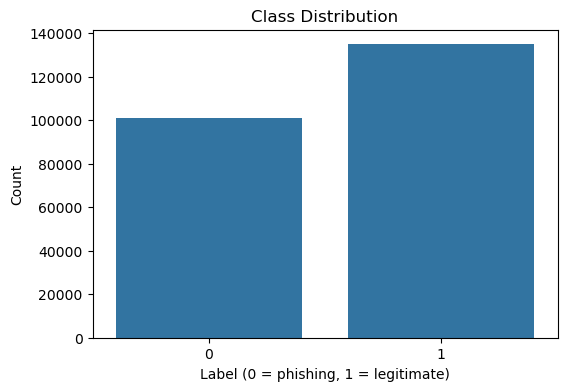

In [5]:
# checking how many phishing and how many legitimate domains are within the dataset
print(df["label"].value_counts())

plt.figure(figsize=(6,4))
sns.countplot(x="label", data=df)
plt.title("Class Distribution")
plt.xlabel("Label (0 = phishing, 1 = legitimate)")
plt.ylabel("Count")
plt.show()

In [6]:
# splitting features from the target
X = df.drop("label", axis=1)
y = df["label"]

print("Feature matrix shape:", X.shape)
print("Target vector shape:", y.shape)

Feature matrix shape: (235795, 9)
Target vector shape: (235795,)


In [7]:
# top 10 most common TLDs
top_tlds = X["TLD"].value_counts().nlargest(10).index
print(top_tlds.values)

# replacing other TLDs with "other"
X["TLD"] = X["TLD"].apply(lambda x: x if x in top_tlds else "other")

# checking the number of categories
print("Unique TLD categories:", X["TLD"].nunique())

['com' 'org' 'net' 'app' 'uk' 'co' 'io' 'de' 'ru' 'au']
Unique TLD categories: 11


In [8]:
# encode the TLD column and remove other
X = pd.get_dummies(X, columns=["TLD"], drop_first=True)

print("Feature matrix after encoding:", X.shape)
X.head()


Feature matrix after encoding: (235795, 18)


,URLLength,IsDomainIP,NoOfDegitsInURL,NoOfOtherSpecialCharsInURL,IsHTTPS,DomainLength,NoOfSubDomain,HasObfuscation,TLD_au,TLD_co,TLD_com,TLD_de,TLD_io,TLD_net,TLD_org,TLD_other,TLD_ru,TLD_uk
0,31,0,0,1,1,24,1,0,False,False,True,False,False,False,False,False,False,False
1,23,0,0,2,1,16,1,0,False,False,False,True,False,False,False,False,False,False
2,29,0,0,2,1,22,2,0,False,False,False,False,False,False,False,False,False,True
3,26,0,0,1,1,19,1,0,False,False,True,False,False,False,False,False,False,False
4,33,0,0,1,1,26,1,0,False,False,False,False,False,False,True,False,False,False


In [9]:
# splitting data into training and testing
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Training set shape:", X_train.shape)
print("Test set shape:", X_test.shape)

Training set shape: (188636, 18)
Test set shape: (47159, 18)


In [10]:
# scaling 
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Scaled training shape:", X_train_scaled.shape)
print("Scaled test shape:", X_test_scaled.shape)

Scaled training shape: (188636, 18)
Scaled test shape: (47159, 18)


In [11]:
# creating a validation split from the training data
X_train_final, X_val, y_train_final, y_val = train_test_split(
    X_train_scaled, y_train,
    test_size=0.1,
    random_state=42,
    stratify=y_train
)

print("Final training shape:", X_train_final.shape)
print("Validation shape:", X_val.shape)
print("Test shape:", X_test_scaled.shape)

Final training shape: (169772, 18)
Validation shape: (18864, 18)
Test shape: (47159, 18)


In [12]:
# random seed for reproducibility
tf.random.set_seed(42)

# building the ANN model
model_nn = models.Sequential([
    layers.Input(shape=(X_train_final.shape[1],)),
    
    layers.Dense(64, activation="relu", name="hidden_1"),
    layers.Dropout(0.3, name="dropout_1"),
    
    layers.Dense(32, activation="relu", name="hidden_2"),
    layers.Dropout(0.3, name="dropout_2"),
    
    layers.Dense(1, activation="sigmoid", name="output")
], name="Phishing_URL_ANN")

print("Model built successfully!")

Model built successfully!


In [13]:
model_nn.summary()

Model: "Phishing_URL_ANN"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ hidden_1 (Dense)                │ (None, 64)             │         1,216 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ hidden_2 (Dense)                │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output (Dense)                  │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,329 (13.00 KB)

 Trainable params: 3,329 (13.00 KB)

 Non-trainable params: 0 (0.00 B)

In [14]:
# compiling the model
model_nn.compile(
    optimizer="adam",
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

print("Model compiled successfully.")

Model compiled successfully.


In [15]:
# callbacks
early_stopping = EarlyStopping(
    monitor="val_loss",
    patience=5,
    restore_best_weights=True,
    verbose=1
)

reduce_lr = ReduceLROnPlateau(
    monitor="val_loss",
    factor=0.5,
    patience=3,
    min_lr=1e-6,
    verbose=1
)

callbacks = [early_stopping, reduce_lr]
print("Callbacks configured.")

Callbacks configured.


In [16]:
# training the neural network
history = model_nn.fit(
    X_train_final,
    y_train_final,
    epochs=30,
    batch_size=128,
    validation_data=(X_val, y_val),
    callbacks=callbacks,
    verbose=1
)

Epoch 1/30
1327/1327 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.9660 - loss: 0.0976 - val_accuracy: 0.9878 - val_loss: 0.0429 - learning_rate: 0.0010
Epoch 2/30
1327/1327 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.9876 - loss: 0.0439 - val_accuracy: 0.9878 - val_loss: 0.0393 - learning_rate: 0.0010
Epoch 3/30
1327/1327 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.9886 - loss: 0.0401 - val_accuracy: 0.9887 - val_loss: 0.0371 - learning_rate: 0.0010
Epoch 4/30
1327/1327 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.9892 - loss: 0.0376 - val_accuracy: 0.9890 - val_loss: 0.0350 - learning_rate: 0.0010
Epoch 5/30
1327/1327 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.9901 - loss: 0.0353 - val_accuracy: 0.9902 - val_loss: 0.0313 - learning_rate: 0.0010
Epoch 6/30
1327/1327 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.9913 - loss: 0.0319 - val_accuracy: 0.9933 - val_loss: 0.0274 - learning_rate: 0.0010
Epoch 7/30
1327/1327 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.9935 - l

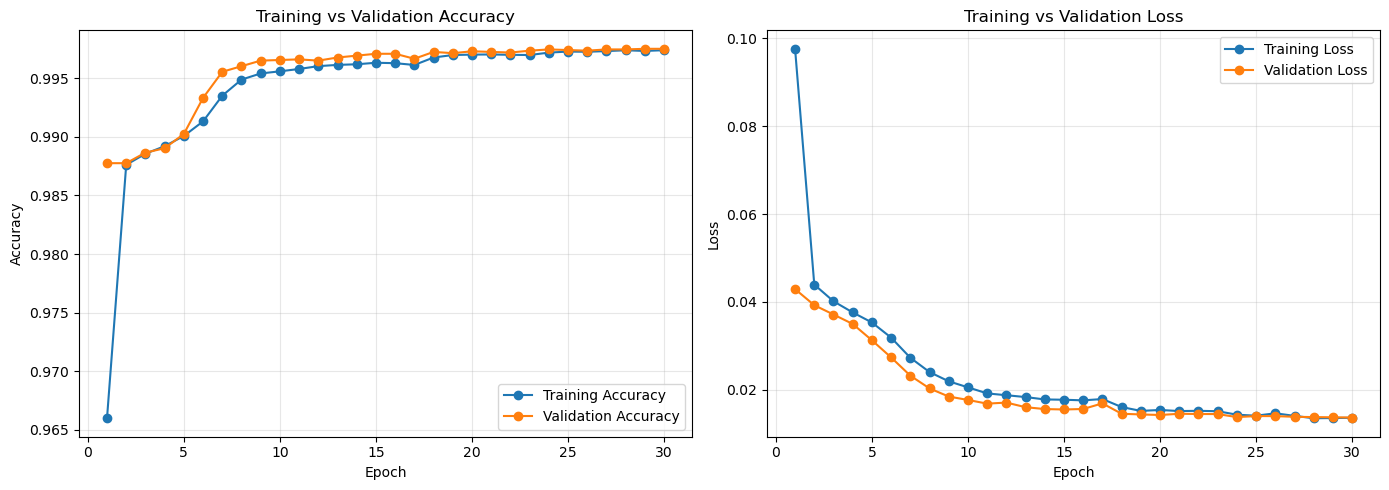

In [17]:
# plotting training history
train_acc = history.history["accuracy"]
val_acc = history.history["val_accuracy"]
train_loss = history.history["loss"]
val_loss = history.history["val_loss"]

epochs_range = range(1, len(train_acc) + 1)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# accuracy plot
ax1.plot(epochs_range, train_acc, marker="o", label="Training Accuracy")
ax1.plot(epochs_range, val_acc, marker="o", label="Validation Accuracy")
ax1.set_title("Training vs Validation Accuracy")
ax1.set_xlabel("Epoch")
ax1.set_ylabel("Accuracy")
ax1.legend()
ax1.grid(True, alpha=0.3)

# loss plot
ax2.plot(epochs_range, train_loss, marker="o", label="Training Loss")
ax2.plot(epochs_range, val_loss, marker="o", label="Validation Loss")
ax2.set_title("Training vs Validation Loss")
ax2.set_xlabel("Epoch")
ax2.set_ylabel("Loss")
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [18]:
# evaluating the model on the test set
test_loss, test_accuracy = model_nn.evaluate(X_test_scaled, y_test, verbose=0)

print("Neural Network Test Performance:")
print(f"Accuracy : {test_accuracy:.4f}")
print(f"Loss     : {test_loss:.4f}")

Neural Network Test Performance:
Accuracy : 0.9971
Loss     : 0.0155


In [19]:
# generating predictions
y_prob_nn = model_nn.predict(X_test_scaled, verbose=0).ravel()
y_pred_nn = (y_prob_nn >= 0.5).astype(int)

print("Predictions created.")
print(y_pred_nn[:10])

Predictions created.
[1 1 1 1 1 0 1 1 1 0]


In [20]:
# evaluation
accuracy = accuracy_score(y_test, y_pred_nn)
precision = precision_score(y_test, y_pred_nn)
recall = recall_score(y_test, y_pred_nn)
f1 = f1_score(y_test, y_pred_nn)

print("Neural Network Performance:")
print(f"Accuracy : {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall   : {recall:.4f}")
print(f"F1 Score : {f1:.4f}")

Neural Network Performance:
Accuracy : 0.9971
Precision: 0.9955
Recall   : 0.9994
F1 Score : 0.9974


Confusion Matrix:
[[20066   123]
 [   15 26955]]


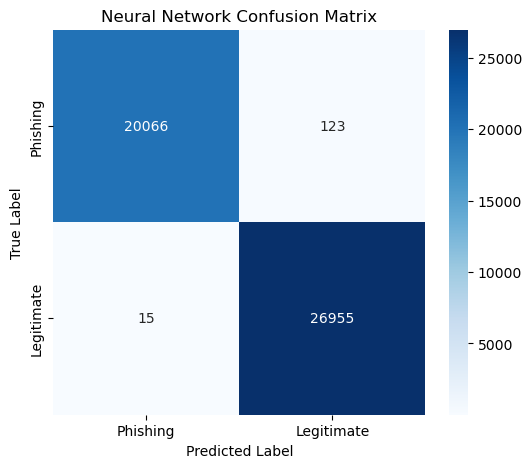

In [21]:
# creating a confusion matrix and graph
cm = confusion_matrix(y_test, y_pred_nn)

print("Confusion Matrix:")
print(cm)

plt.figure(figsize=(6,5))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Phishing", "Legitimate"],
    yticklabels=["Phishing", "Legitimate"]
)
plt.title("Neural Network Confusion Matrix")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.show()

In [22]:
print("Classification Report:")
print(classification_report(y_test, y_pred_nn, target_names=["Phishing", "Legitimate"]))

Classification Report:
              precision    recall  f1-score   support

    Phishing       1.00      0.99      1.00     20189
  Legitimate       1.00      1.00      1.00     26970

    accuracy                           1.00     47159
   macro avg       1.00      1.00      1.00     47159
weighted avg       1.00      1.00      1.00     47159



In [23]:
# saving the neural model
model_nn.save("../models/neural_network_model.keras")

# saving the preprocessing objects for streamlit
joblib.dump(scaler, "../models/neural_network_scaler.pkl")
joblib.dump(list(top_tlds), "../models/neural_network_top_tlds.pkl")

print("files saved.")

files saved.


### Conclusion
Better results than the decision tree model. 130 false negatives and 14 false positives.

In [24]:
print("ANN parameter count:", model_nn.count_params())

ANN parameter count: 3329
